In [1]:
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader
from torchvision.transforms import v2
import torch
from torch import nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_data = MNIST(root="data", train=True, download=True, transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)]))

In order to train an embedding model, we'll want to load our data as pairs of similar and dissimilar classes. Then when constructing our loss, we will have 'labels' of whether or not the pairs should be close or far apart in the embedding space.

To achieve this, we create a `Sampler` we can give to a `DataLoader` so this logic of finding pairs with the same or different labels doesn't interfere with our training loop.

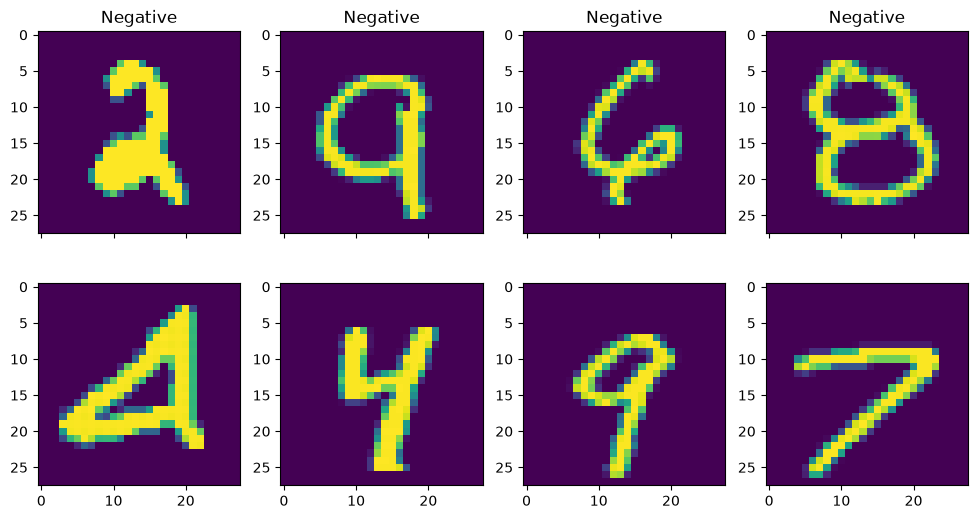

In [2]:
from torch.utils.data import Sampler
from typing import Sequence, Iterator
import numpy as np
from collections import defaultdict
import random
from itertools import islice

class EmbeddingBatchedSampler(Sampler):
    def __init__(self, data: Sequence[torch.Tensor], batch_size: int) -> None:
        self.data = data
        self.batch_size = batch_size
        self.image_lookup: defaultdict[int, list[int]] = defaultdict(lambda: [])
        for i, (_, label) in enumerate(self.data):
            self.image_lookup[label].append(i)

    def __iter__(self) -> Iterator[tuple[torch.Tensor]]:
        indices = np.arange(len(self.data))
        np.random.shuffle(indices)

        indices = iter(indices)

        while True:
            batch = []
            labels = []
            done = False
            for _ in range(self.batch_size):
                try:
                    index = next(indices)
                except StopIteration:
                    done = True
                    break
                _, label = self.data[index]
                positive = True
                if random.random() < 0.5:
                    positive = False
                    neg_label = label
                    while neg_label == label:
                        neg_label = random.choice(range(10))
                    label = neg_label
                complement_idx = random.choice(self.image_lookup[label])
                batch.append(torch.stack((self.data[index][0], self.data[complement_idx][0]), axis=0))
                labels.append(int(positive))
            if not batch or not labels:
                return
            yield torch.stack(batch, axis=0), torch.Tensor(labels)
            if done:
                return

train_loader = DataLoader(train_data, sampler=EmbeddingBatchedSampler(train_data, batch_size=64))

import matplotlib.pyplot as plt

for pairs, labels in (islice(EmbeddingBatchedSampler(train_data, batch_size=64), 1)):
    pairs = pairs.to(device).flatten(-3)

    fig = plt.figure(figsize=(12, 6))
    axes = fig.subplots(2, 4, sharex=True)
    for i, (ax1, ax2) in enumerate(zip(*axes)):
        ax1.set_title('Positive' if labels[i] else 'Negative')
        ax1.imshow(pairs[i][0].cpu().reshape(28, 28))
        ax2.imshow(pairs[i][1].cpu().reshape(28, 28))

Now with the data prepared, we can train our first embedding model. We'll just use an MLP with two hidden layers and ReLU between layers. To allow our output to have negative values, we'll stay without an activation function at this moment. We'll want to do cosine similarity, which will also help us have somewhat meaningful answers when we're done, i.e. a similarity score between -1 and 1.

In [3]:
from torch import nn, optim

LATENT_DIMS = 64
EPOCHS = 10

model = nn.Sequential(nn.Linear(28 * 28, 512), nn.ReLU(), nn.Linear(512, 512), nn.ReLU(), nn.Linear(512, LATENT_DIMS))
model = model.to(device)

loss = nn.CosineEmbeddingLoss()
optimizer = optim.Adam(model.parameters(), lr=3e-4)

for epoch in range(EPOCHS):
    total_loss = 0
    for pairs, labels in EmbeddingBatchedSampler(train_data, batch_size=32):
        pairs = pairs.flatten(-3).to(device)
        labels = labels.to(device)
        labels = 2 * labels - 1

        embeddings = model(pairs)
        embedding0 = embeddings[:, 0, ...]
        embedding1 = embeddings[:, 1, ...]
        output = loss(embedding0, embedding1, labels)
        total_loss += output.item()
        output.backward()
        optimizer.step()
    print(f'Epoch {epoch + 1} complete, epoch total loss = {total_loss:1.3f}')

Epoch 1 complete, epoch total loss = 356.373
Epoch 2 complete, epoch total loss = 289.305
Epoch 3 complete, epoch total loss = 268.485
Epoch 4 complete, epoch total loss = 243.469
Epoch 5 complete, epoch total loss = 222.743
Epoch 6 complete, epoch total loss = 214.925
Epoch 7 complete, epoch total loss = 206.641
Epoch 8 complete, epoch total loss = 203.907
Epoch 9 complete, epoch total loss = 203.313
Epoch 10 complete, epoch total loss = 201.127


Now let's run see some distances between positive and negative pairs, as some rough empirical evidence of how well this model performs.

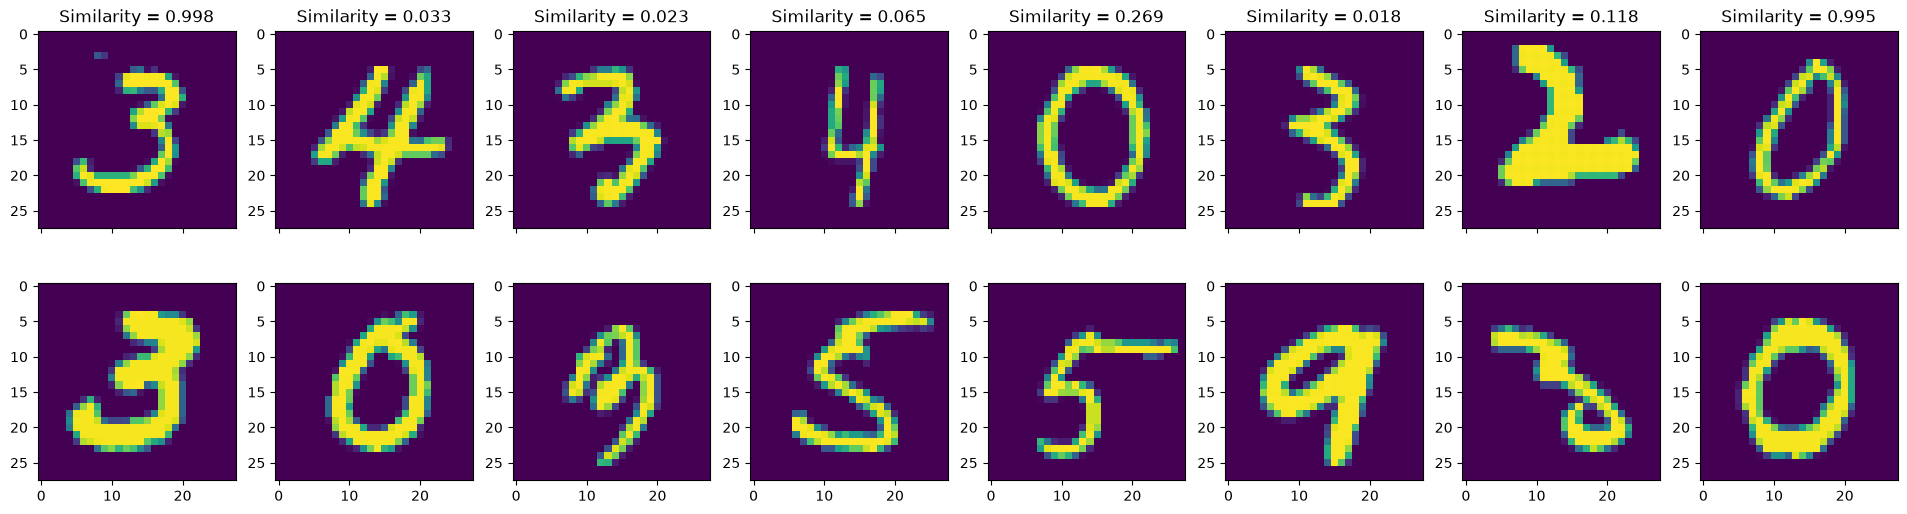

In [4]:
import torch.nn.functional as F

for pairs, labels in (islice(EmbeddingBatchedSampler(train_data, batch_size=64), 1)):
    pairs = pairs.to(device).flatten(-3)

    fig = plt.figure(figsize=(24, 6))
    axes = fig.subplots(2, 8, sharex=True)
    for i, (ax1, ax2) in enumerate(zip(*axes)):
        with torch.no_grad():
            embeddings = model(pairs[i])
        embedding0 = embeddings[0, ...]
        embedding1 = embeddings[1, ...]
        embedding0 = embedding0 / embedding0.norm()
        embedding1 = embedding1 / embedding1.norm()
        similarity = torch.dot(embedding0, embedding1).norm().cpu()
        ax1.set_title(f'Similarity = {similarity:1.3f}')
        ax1.imshow(pairs[i][0].cpu().reshape(28, 28))
        ax2.imshow(pairs[i][1].cpu().reshape(28, 28))

For most examples, the results are quite decent, although it can get a little confused. Although, we won't tweak this model to get better performance since this notebook is only about how we go about training an embedding model in the first place, and we've already learned about loading similar pairs and the general training loop.